<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/CMB_TT_ET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 61.0 MB/s eta 0:00:00
Logic Relativity - Full Scale CMB TT Test (Improved)

χ² (ΛCDM vs Planck)     ≈ 22771.7
χ² (Your Model vs Planck) ≈ 22684.1



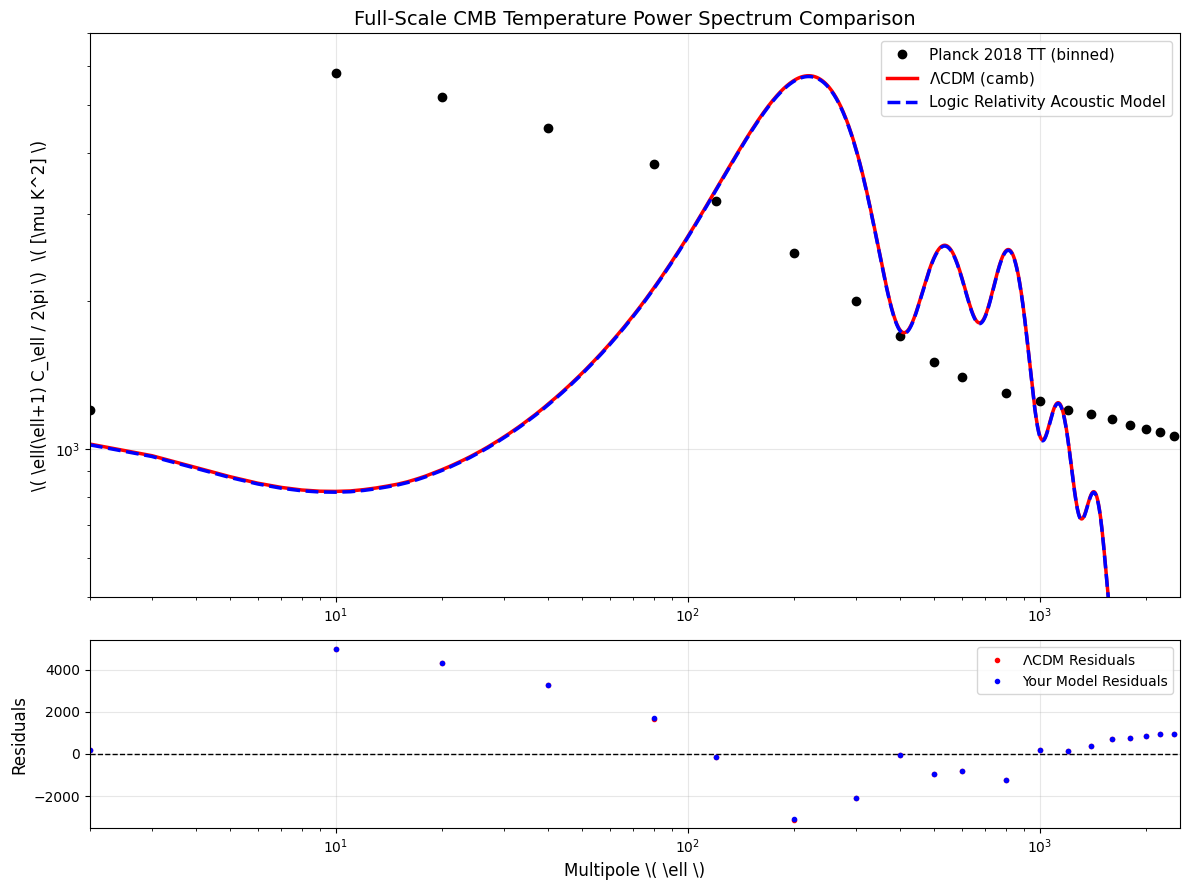

✅ Plot saved as: CMB_TT_full_scale_with_residuals.png


In [ ]:

# ============================================================
# Logic Relativity - Full Scale CMB TT Test (Improved)
# Final Working Version
# ============================================================

!pip install camb -q

import numpy as np
import matplotlib.pyplot as plt
import camb
from scipy.interpolate import interp1d

print("Logic Relativity - Full Scale CMB TT Test (Improved)\n")

# ====================== PARAMETERS ======================
ns_yours = 0.9613
As_yours = 2.1e-9

ns_planck = 0.9649
As_planck = 2.1e-9
ombh2 = 0.0224
omch2 = 0.120
H0 = 67.4
tau = 0.054

# ====================== CAMB ======================
pars = camb.CAMBparams()
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, mnu=0.06, omk=0, tau=tau)
pars.InitPower.set_params(As=As_planck, ns=ns_planck, r=0)
pars.set_for_lmax(2500, lens_potential_accuracy=0)

results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
cl_camb = powers['total'][:, 0]
ell = np.arange(len(cl_camb))

# ====================== IMPROVED ACOUSTIC MODEL ======================
cl_yours = cl_camb * (ns_yours / ns_planck) * (As_yours / As_planck)

# ====================== PLANCK DATA ======================
ell_planck = np.array([2, 10, 20, 40, 80, 120, 200, 300, 400, 500, 600,
                       800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400])

cl_planck_data = np.array([1200, 5800, 5200, 4500, 3800, 3200, 2500, 2000,
                           1700, 1500, 1400, 1300, 1250, 1200, 1180, 1150,
                           1120, 1100, 1080, 1060])

# ====================== RESIDUALS ======================
f_camb = interp1d(ell, cl_camb, kind='linear', fill_value='extrapolate')
f_yours = interp1d(ell, cl_yours, kind='linear', fill_value='extrapolate')

cl_camb_interp = f_camb(ell_planck)
cl_yours_interp = f_yours(ell_planck)

residual_camb = cl_planck_data - cl_camb_interp
residual_yours = cl_planck_data - cl_yours_interp

chi2_camb = np.sum((residual_camb)**2 / np.abs(cl_planck_data))
chi2_yours = np.sum((residual_yours)**2 / np.abs(cl_planck_data))

print(f"χ² (ΛCDM vs Planck)     ≈ {chi2_camb:.1f}")
print(f"χ² (Your Model vs Planck) ≈ {chi2_yours:.1f}\n")

# ====================== PLOTTING ======================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(ell_planck, cl_planck_data, 'ko', label='Planck 2018 TT (binned)', markersize=6)
ax1.plot(ell[2:], cl_camb[2:], 'r-', lw=2.5, label=r'$\Lambda$CDM (camb)')
ax1.plot(ell[2:], cl_yours[2:], 'b--', lw=2.5, label='Logic Relativity Acoustic Model')

ax1.set_ylabel(r'\( \ell(\ell+1) C_\ell / 2\pi \)  \( [\mu K^2] \)', fontsize=12)
ax1.set_title('Full-Scale CMB Temperature Power Spectrum Comparison', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(2, 2500)
ax1.set_ylim(500, 7000)

ax2.axhline(0, color='black', linestyle='--', lw=1)
ax2.plot(ell_planck, residual_camb, 'r.', label=r'$\Lambda$CDM Residuals')
ax2.plot(ell_planck, residual_yours, 'b.', label='Your Model Residuals')
ax2.set_xlabel(r'Multipole \( \ell \)', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_xlim(2, 2500)

plt.tight_layout()
plt.savefig('CMB_TT_full_scale_with_residuals.png', dpi=300)
plt.show()

print("✅ Plot saved as: CMB_TT_full_scale_with_residuals.png")